# Sprint 4 — Step 1 Audit: shortcuts, labels, protocol, screening metrics

**Project:** Q-INTERVAL-Lite+ · **Author:** Pasindu Pahasara (104348348)

Execution-order step 1 from the maxout checklist. Six analyses, all cheap. Everything after
section 3 runs on cached probabilities with no GPU.

| § | Analysis | Why |
|---|---|---|
| 2 | Label-semantics audit per source | Benign may mean different things across the five sources |
| 3 | Source-shortcut ablation, 4 variants | Model receives dataset identity as an input — measure how much it uses it |
| 4 | Validation-protocol freeze | Subsets, weights, coefficients and checkpoints were all chosen on one 830-patient set |
| 5 | Screening-prevalence metrics | Test set is 44.5% malignant; screening is under 1% |
| 6 | Bootstrap confidence intervals | Run-to-run variance measured at ~3 pts — several table differences may be noise |
| 7 | Selective prediction / deferral | Radiology 2025: 38% workload reduction at maintained recall |

**The number this notebook exists to produce** is section 3's: how much of 0.7451 is
pathology and how much is dataset recognition.

## 1. Setup

In [ ]:
!pip install -q albumentations scikit-learn tqdm matplotlib seaborn efficientnet_pytorch

import os, json, itertools, random
import numpy as np
import pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet101, efficientnet_v2_s
from efficientnet_pytorch import EfficientNet
import cv2, albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (accuracy_score, f1_score, recall_score, precision_score,
                             roc_auc_score, average_precision_score, brier_score_loss,
                             matthews_corrcoef, confusion_matrix, classification_report,
                             roc_curve)
import matplotlib.pyplot as plt, seaborn as sns
from tqdm.notebook import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
CLASS_NAMES = ['Normal', 'Benign', 'Malignant']
MAL = 2
print('Device:', device)

  Preparing metadata (setup.py) ... done
Device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT  = '/content/drive/MyDrive/momobench-dataset'
EXTRACT_DIR = '/content/dataset_original'
OUT_DIR     = os.path.join(DRIVE_ROOT, 'sprint4_audit')
os.makedirs(OUT_DIR, exist_ok=True)

if not os.path.isdir(os.path.join(EXTRACT_DIR, 'dataset')):
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    os.system(f'unzip -q "{DRIVE_ROOT}/dataset.zip" -d "{EXTRACT_DIR}"')
    print('extracted')
else:
    print('already extracted')
IMG_ROOT  = os.path.join(EXTRACT_DIR, 'dataset')
META_PATH = os.path.join(IMG_ROOT, 'metadata.csv')
print('metadata:', os.path.exists(META_PATH))

Mounted at /content/drive
extracted
metadata: True


In [ ]:
# Rebuild the exact split used by every model
df = pd.read_csv(META_PATH)
df['classification'] = df['classification'].replace({'Suspicious Malignant': 'Malignant'})
df = df[df['source_dataset'] != 'cdd-cesm'].reset_index(drop=True)
df['image_path'] = df['preprocessed_image_path'].apply(lambda r: os.path.join(IMG_ROOT, r))
df = df[df['image_path'].apply(os.path.exists)].reset_index(drop=True)
df['label'] = df['classification'].map({c: i for i, c in enumerate(CLASS_NAMES)})

def age_bucket(a):
    if pd.isna(a): return 7
    for i, hi in enumerate([30, 40, 50, 60, 70, 80]):
        if a < hi: return i
    return 6
df['age_idx']  = df['subject_age'].apply(age_bucket); N_AGE = 8
df['view_idx'] = df['view'].map({'CC': 0, 'MLO': 1}).fillna(2).astype(int); N_VIEW = 3
df['lat_idx']  = df['laterality'].map({'L': 0, 'R': 1}).astype(int); N_LAT = 2
SOURCE_NAMES = sorted(df['source_dataset'].unique())
df['src_idx'] = df['source_dataset'].map({s: i for i, s in enumerate(SOURCE_NAMES)})
N_SRC = len(SOURCE_NAMES)

SEV = {'Normal': 0, 'Benign': 1, 'Malignant': 2}
pat = (df.assign(sev=df['classification'].map(SEV))
         .groupby('source_subjectID')
         .agg(sev=('sev','max'), source_dataset=('source_dataset','first')).reset_index())
pat['strat'] = pat['sev'].map({0:'Normal',1:'Benign',2:'Malignant'}) + '|' + pat['source_dataset']
train_pat, temp_pat = train_test_split(pat, test_size=0.30, stratify=pat['strat'], random_state=SEED)
val_pat, test_pat   = train_test_split(temp_pat, test_size=0.50, stratify=temp_pat['strat'], random_state=SEED)

train_df = df[df['source_subjectID'].isin(set(train_pat['source_subjectID']))].reset_index(drop=True)
val_df   = df[df['source_subjectID'].isin(set(val_pat['source_subjectID']))].reset_index(drop=True)
test_df  = df[df['source_subjectID'].isin(set(test_pat['source_subjectID']))].reset_index(drop=True)
val_labels, test_labels = val_df['label'].to_numpy(), test_df['label'].to_numpy()
print(f'train {len(train_df)}  val {len(val_df)}  test {len(test_df)}   sources: {SOURCE_NAMES}')

train 13093  val 2814  test 2821   sources: ['cmmd', 'ddsm', 'dmid', 'inbreast', 'kau-bcmd']


In [ ]:
# Cached per-model calibrated probabilities from the Tier 1 notebook
CACHE = os.path.join(DRIVE_ROOT, 'sprint4_tier1', 'per_model_probs.npz')
z = np.load(CACHE, allow_pickle=True)
val_probs  = {k[4:]: z[k] for k in z.files if k.startswith('val_')}
test_probs = {k[5:]: z[k] for k in z.files if k.startswith('test_')}
print('cached members:', list(test_probs.keys()))

def ens(pd_, members, weights=None):
    if weights is None: weights = {m: 1.0 for m in members}
    w = np.array([weights[m] for m in members], float); w /= w.sum()
    return (np.stack([pd_[m] for m in members]) * w[:, None, None]).sum(0)

def evaluate(probs, y, name='', pred=None):
    if pred is None: pred = probs.argmax(1)
    f1s = f1_score(y, pred, average=None, labels=[0,1,2])
    return {'model': name,
            'accuracy':   accuracy_score(y, pred),
            'macro_f1':   f1_score(y, pred, average='macro'),
            'mal_recall': recall_score(y, pred, labels=[MAL], average='macro'),
            'benign_f1':  f1s[1],
            'macro_auc':  roc_auc_score(y, probs, multi_class='ovr', average='macro'),
            'mcc':        matthews_corrcoef(y, pred)}

# Final Sprint 4 configuration
BEST     = ['v5', 'v6']
IND_VAL  = {m: evaluate(val_probs[m], val_labels, m) for m in BEST}
W_BEST   = {m: IND_VAL[m]['macro_f1'] ** 4 for m in BEST}
COEF     = np.array([1.0, 1.75, 1.70])
test_ens = ens(test_probs, BEST, W_BEST)
pred_ens = (test_ens * COEF).argmax(1)
print('\nFinal config reproduced:')
print({k: round(v,4) for k,v in evaluate(test_ens, test_labels, 'v5+v6 tuned',
                                          pred=pred_ens).items() if k!='model'})

cached members: ['v4', 'v5', 'v6', 'mammofm']

Final config reproduced:
{'accuracy': 0.7373, 'macro_f1': 0.7415, 'mal_recall': 0.7811, 'benign_f1': np.float64(0.634), 'macro_auc': np.float64(0.8918), 'mcc': np.float64(0.5908)}


## 2. Label-semantics audit

If "Benign" is constructed differently across the five sources, the model is being asked to
fit an inconsistent target — which would cap Benign F1 regardless of architecture. Two
signals: does class distribution differ sharply by source, and does per-source performance
differ sharply.

In [ ]:
print('CLASS DISTRIBUTION BY SOURCE (row-normalised)')
dist = pd.crosstab(df['source_dataset'], df['classification'], normalize='index').round(3)
display(dist)
print('\nIMAGE COUNTS BY SOURCE')
display(pd.crosstab(df['source_dataset'], df['classification'], margins=True))

# how separable are the sources by class alone?
spread = (dist.max(axis=0) - dist.min(axis=0)).round(3)
print('\nAcross-source spread in class proportion:')
print(spread)
print('\nIf spread is large, source identity is informative about class by construction.')

CLASS DISTRIBUTION BY SOURCE (row-normalised)


classification,Benign,Malignant,Normal
source_dataset,,,
cmmd,0.213,0.787,0.000
ddsm,0.382,0.352,0.267
dmid,0.302,0.282,0.416
inbreast,0.593,0.244,0.163
kau-bcmd,0.120,0.043,0.837



IMAGE COUNTS BY SOURCE


classification,Benign,Malignant,Normal,All
source_dataset,,,,
cmmd,1108,4094,0,5202
ddsm,3968,3656,2776,10400
dmid,154,144,212,510
inbreast,243,100,67,410
kau-bcmd,265,94,1847,2206
All,5738,8088,4902,18728



Across-source spread in class proportion:
classification
Benign       0.473
Malignant    0.744
Normal       0.837
dtype: float64

If spread is large, source identity is informative about class by construction.


In [ ]:
# Per-source performance of the final ensemble on the test set
rows = []
test_src = test_df['source_dataset'].to_numpy()
for s in SOURCE_NAMES:
    m = test_src == s
    if m.sum() < 30:
        print(f'{s}: only {m.sum()} test images - skipped'); continue
    y, p = test_labels[m], test_ens[m]
    pr = (p * COEF).argmax(1)
    f1s = f1_score(y, pr, average=None, labels=[0,1,2], zero_division=0)
    rows.append({'source': s, 'n': int(m.sum()),
                 'accuracy': accuracy_score(y, pr),
                 'macro_f1': f1_score(y, pr, average='macro', zero_division=0),
                 'benign_f1': f1s[1],
                 'mal_recall': recall_score(y, pr, labels=[MAL], average='macro', zero_division=0)})
per_src = pd.DataFrame(rows).set_index('source').round(4)
display(per_src)
print(f"\nBenign F1 range across sources: {per_src['benign_f1'].min():.3f} to "
      f"{per_src['benign_f1'].max():.3f}  (spread {per_src['benign_f1'].max()-per_src['benign_f1'].min():.3f})")
print('A wide spread indicates the Benign label is not consistently defined across sources.')

,n,accuracy,macro_f1,benign_f1,mal_recall
source,,,,,
cmmd,826,0.8002,0.5907,0.2979,0.9514
ddsm,1528,0.6616,0.6689,0.6726,0.6168
dmid,76,0.6184,0.6058,0.5424,0.4286
inbreast,61,0.7049,0.5177,0.8000,0.4000
kau-bcmd,330,0.9636,0.7065,0.8696,0.1429



Benign F1 range across sources: 0.298 to 0.870  (spread 0.572)
A wide spread indicates the Benign label is not consistently defined across sources.


## 3. Source-shortcut ablation — the key result

Four variants:

1. **Current** — metadata including the source embedding
2. **Source masked** — same weights, source embedding zeroed at inference
3. **Metadata-only** — logistic regression on metadata alone, no image at all
4. **Image-only** — v4, which was trained with no metadata whatsoever

Variant 3 is the sharpest test: if metadata alone predicts class well above chance, the
model has a shortcut available. Variant 4 gives the honest image-only floor.

In [ ]:
# --- Variant 3: metadata-only, no image ---
feat_cols = ['age_idx', 'view_idx', 'lat_idx', 'src_idx']
enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
Xtr = enc.fit_transform(train_df[feat_cols]); ytr = train_df['label'].to_numpy()
Xte = enc.transform(test_df[feat_cols])

lr_all = LogisticRegression(max_iter=2000, multi_class='multinomial').fit(Xtr, ytr)
p_meta = lr_all.predict_proba(Xte)

# source alone
enc_s = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
Xtr_s = enc_s.fit_transform(train_df[['src_idx']]); Xte_s = enc_s.transform(test_df[['src_idx']])
lr_src = LogisticRegression(max_iter=2000, multi_class='multinomial').fit(Xtr_s, ytr)
p_src = lr_src.predict_proba(Xte_s)

chance = max(np.bincount(test_labels) / len(test_labels))
print(f'Majority-class baseline: {chance:.4f}\n')
display(pd.DataFrame([
    evaluate(p_src,  test_labels, 'SOURCE ONLY (no image, no other metadata)'),
    evaluate(p_meta, test_labels, 'ALL METADATA ONLY (no image)'),
]).set_index('model').round(4))
print('\nIf SOURCE ONLY is well above the majority baseline, dataset identity carries')
print('class information and the source embedding is an exploitable shortcut.')

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Majority-class baseline: 0.4452



,accuracy,macro_f1,mal_recall,benign_f1,macro_auc,mcc
model,,,,,,
"SOURCE ONLY (no image, no other metadata)",0.5650,0.5664,0.5239,0.5131,0.7346,0.3722
ALL METADATA ONLY (no image),0.5927,0.5703,0.7564,0.4753,0.7656,0.3566



If SOURCE ONLY is well above the majority baseline, dataset identity carries
class information and the source embedding is an exploitable shortcut.


In [ ]:
# --- Variants 1, 2, 4: model-based ---
BUNDLES = {
    'v4': f'{DRIVE_ROOT}/checkpoints_wk12_v4/final_resnet101_wk12_v4_bundle.pth',
    'v5': f'{DRIVE_ROOT}/checkpoints_wk12_v5/final_resnet101_wk12_v5_bundle.pth',
    'v6': f'{DRIVE_ROOT}/checkpoints_wk12_v6/final_effnetv2_cbam_wk12_v6_bundle.pth',
}

class CBAM(nn.Module):
    def __init__(self, c, r=16, k=7):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool2d(1); self.mx = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(nn.Conv2d(c, c//r, 1, bias=False), nn.ReLU(inplace=True),
                                 nn.Conv2d(c//r, c, 1, bias=False))
        self.sp = nn.Conv2d(2, 1, k, padding=k//2, bias=False)
    def forward(self, x):
        x = x * torch.sigmoid(self.mlp(self.avg(x)) + self.mlp(self.mx(x)))
        return x * torch.sigmoid(self.sp(torch.cat([x.mean(1, keepdim=True),
                                                    x.amax(1, keepdim=True)], 1)))

class ResNet101_Meta(nn.Module):
    def __init__(self, emb=16, nc=3, dr=0.3):
        super().__init__()
        self.backbone = resnet101(weights=None); self.backbone.fc = nn.Identity()
        self.age_emb=nn.Embedding(N_AGE,emb); self.view_emb=nn.Embedding(N_VIEW,emb)
        self.lat_emb=nn.Embedding(N_LAT,emb); self.src_emb=nn.Embedding(N_SRC,emb)
        self.classifier = nn.Sequential(nn.Dropout(dr), nn.Linear(2048+4*emb,256),
                                        nn.ReLU(inplace=True), nn.Dropout(dr), nn.Linear(256,nc))
    def forward(self, x, a, v, l, s):
        f = self.backbone(x)
        m = torch.cat([self.age_emb(a), self.view_emb(v), self.lat_emb(l), self.src_emb(s)], 1)
        return self.classifier(torch.cat([f, m], 1))

class EffNetV2_CBAM_Meta(nn.Module):
    def __init__(self, emb=16, nc=3, dr=0.3):
        super().__init__()
        self.features = efficientnet_v2_s(weights=None).features
        self.cbam = CBAM(1280); self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.age_emb=nn.Embedding(N_AGE,emb); self.view_emb=nn.Embedding(N_VIEW,emb)
        self.lat_emb=nn.Embedding(N_LAT,emb); self.src_emb=nn.Embedding(N_SRC,emb)
        self.classifier = nn.Sequential(nn.Dropout(dr), nn.Linear(1280+4*emb,256),
                                        nn.ReLU(inplace=True), nn.Dropout(dr), nn.Linear(256,nc))
    def forward(self, x, a, v, l, s):
        f = self.avgpool(self.cbam(self.features(x))).flatten(1)
        m = torch.cat([self.age_emb(a), self.view_emb(v), self.lat_emb(l), self.src_emb(s)], 1)
        return self.classifier(torch.cat([f, m], 1))

class TTAData(Dataset):
    def __init__(self, d, mean, std, size):
        self.df = d.reset_index(drop=True)
        self.tf = A.Compose([A.Resize(size,size), A.Normalize(mean=mean,std=std), ToTensorV2()])
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = cv2.cvtColor(cv2.imread(r['image_path']), cv2.COLOR_BGR2RGB)
        return (self.tf(image=img)['image'], int(r['age_idx']), int(r['view_idx']),
                int(r['lat_idx']), int(r['src_idx']), int(r['label']))

@torch.no_grad()
def predict(model, d, mean, std, size, T, use_meta=True,
            tta=('none','hflip','vflip','both')):
    dl = DataLoader(TTAData(d, mean, std, size), batch_size=32, shuffle=False,
                    num_workers=2, pin_memory=True)
    out = np.zeros((len(d), 3), np.float32); i = 0
    model.eval()
    for x, a, v, l, s, _ in tqdm(dl, leave=False):
        x = x.to(device); a,v,l,s = a.to(device),v.to(device),l.to(device),s.to(device)
        acc = None
        for mode in tta:
            xi = x
            if mode in ('hflip','both'): xi = torch.flip(xi, dims=[3])
            if mode in ('vflip','both'): xi = torch.flip(xi, dims=[2])
            with torch.amp.autocast(device_type='cuda'):
                lg = model(xi, a, v, l, s) if use_meta else model(xi)
            p = F.softmax(lg.float()/T, 1)
            acc = p if acc is None else acc + p
        p = (acc/len(tta)).cpu().numpy(); out[i:i+len(p)] = p; i += len(p)
    return out

In [ ]:
FACT = {'v5': ResNet101_Meta, 'v6': EffNetV2_CBAM_Meta}
masked_probs = {}

for name in BEST:
    b = torch.load(BUNDLES[name], map_location=device, weights_only=False)
    m = FACT[name]().to(device)
    m.load_state_dict(b['model_state_dict'], strict=False)
    with torch.no_grad():
        m.src_emb.weight.zero_()          # neutralise source information
    masked_probs[name] = predict(m, test_df, b.get('mean',[0.485,0.456,0.406]),
                                 b.get('std',[0.229,0.224,0.225]),
                                 int(b.get('input_size',384)), float(b.get('temperature',1.0)))
    print(f'{name} source-masked acc: '
          f'{accuracy_score(test_labels, masked_probs[name].argmax(1)):.4f}')
    del m; torch.cuda.empty_cache()

ens_masked = ens(masked_probs, BEST, W_BEST)

rows = [
    evaluate(test_ens,   test_labels, '1. Current (source embedding active)', pred=(test_ens*COEF).argmax(1)),
    evaluate(ens_masked, test_labels, '2. Source embedding masked',          pred=(ens_masked*COEF).argmax(1)),
    evaluate(p_meta,     test_labels, '3. Metadata only, no image'),
    evaluate(test_probs['v4'], test_labels, '4. Image only (v4, no metadata)'),
]
res = pd.DataFrame(rows).set_index('model').round(4)
display(res)

drop = res.iloc[0]['accuracy'] - res.iloc[1]['accuracy']
print(f'\n>>> Accuracy drop when source is masked: {100*drop:+.2f} pp')
if drop > 0.03:   print('    LARGE - a meaningful share of performance is dataset recognition.')
elif drop > 0.01: print('    MODERATE - worth retraining without the source embedding.')
else:             print('    SMALL - image features carry the model. Safe to proceed.')

  0%|          | 0/89 [00:00<?, ?it/s]

v5 source-masked acc: 0.7256


  0%|          | 0/89 [00:00<?, ?it/s]

v6 source-masked acc: 0.6725


,accuracy,macro_f1,mal_recall,benign_f1,macro_auc,mcc
model,,,,,,
1. Current (source embedding active),0.7373,0.7415,0.7811,0.6340,0.8918,0.5908
2. Source embedding masked,0.7178,0.7276,0.7420,0.6370,0.8830,0.5616
"3. Metadata only, no image",0.5927,0.5703,0.7564,0.4753,0.7656,0.3566
"4. Image only (v4, no metadata)",0.7317,0.7337,0.7651,0.6234,0.8801,0.5833



>>> Accuracy drop when source is masked: +1.95 pp
    MODERATE - worth retraining without the source embedding.


## 4. Validation-protocol freeze

Subsets, weights, class coefficients and checkpoints were all selected on the same
830-patient validation set. That accumulates optimistic selection bias, estimated at
0.5–2 points. This carves a fresh model-selection holdout from the training pool so future
tuning has an untouched surface, and leaves the 831-patient test set alone.

In [ ]:
# 15% of TRAIN patients become a new model-selection holdout. Test set untouched.
tr_pat_df = pat[pat['source_subjectID'].isin(set(train_df['source_subjectID']))]
keep_pat, select_pat = train_test_split(tr_pat_df, test_size=0.15,
                                        stratify=tr_pat_df['strat'], random_state=SEED)

new_train = df[df['source_subjectID'].isin(set(keep_pat['source_subjectID']))].reset_index(drop=True)
selection = df[df['source_subjectID'].isin(set(select_pat['source_subjectID']))].reset_index(drop=True)

print(f'New train      : {len(keep_pat):4d} patients  {len(new_train):5d} images')
print(f'Selection set  : {len(select_pat):4d} patients  {len(selection):5d} images   <- tune here from now on')
print(f'Validation     : {len(val_pat):4d} patients  {len(val_df):5d} images   <- already used extensively')
print(f'Test (frozen)  : {len(test_pat):4d} patients  {len(test_df):5d} images   <- final reporting only')

split_spec = {'train': sorted(keep_pat['source_subjectID'].tolist()),
              'selection': sorted(select_pat['source_subjectID'].tolist()),
              'validation': sorted(val_pat['source_subjectID'].tolist()),
              'test': sorted(test_pat['source_subjectID'].tolist()),
              'seed': SEED, 'note': 'test frozen; tune on selection set only'}
with open(os.path.join(OUT_DIR, 'frozen_split.json'), 'w') as f:
    json.dump(split_spec, f, indent=1)
print('\nSaved frozen_split.json')

New train      : 3292 patients  11103 images
Selection set  :  581 patients   1990 images   <- tune here from now on
Validation     :  830 patients   2814 images   <- already used extensively
Test (frozen)  :  831 patients   2821 images   <- final reporting only

Saved frozen_split.json


## 5. Screening-prevalence metrics

The test set is 44.5% malignant. Real screening is 0.5–1%. AUC is prevalence-invariant but
PPV is not, so the same model looks entirely different in a clinic. Reported as PPV, recall
rate per 1,000 and cancer detection rate per 1,000 — the basis Transpara, ProFound and
Lunit studies use.

In [ ]:
y_bin  = (test_labels == MAL).astype(int)
scores = test_ens[:, MAL]
fpr, tpr, thr = roc_curve(y_bin, scores)
spec = 1 - fpr

print(f'Test set prevalence: {y_bin.mean():.4f}  ({y_bin.sum()} of {len(y_bin)})')
print(f'Malignant-vs-rest AUC : {roc_auc_score(y_bin, scores):.4f}')
print(f'PR-AUC (avg precision): {average_precision_score(y_bin, scores):.4f}')
print(f'Brier score           : {brier_score_loss(y_bin, scores):.4f}')

def ppv(sens, sp, prev):
    tp = sens * prev; fp = (1 - sp) * (1 - prev)
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

rows = []
for target in (0.95, 0.90, 0.85, 0.80):
    i = int(np.argmin(np.abs(tpr - target)))
    s, sp = tpr[i], spec[i]
    r = {'sensitivity': round(s,4), 'specificity': round(sp,4)}
    for prev in (0.005, 0.007, 0.010, 0.040, 0.445):
        r[f'PPV@{prev*100:g}%'] = round(ppv(s, sp, prev), 4)
    # screening rates at 0.7% prevalence
    prev = 0.007
    r['recall/1000']  = round(1000 * (s*prev + (1-sp)*(1-prev)), 1)
    r['CDR/1000']     = round(1000 * s * prev, 2)
    rows.append(r)

sc = pd.DataFrame(rows).set_index('sensitivity')
display(sc)
print('\nReference: population screening recall rate is typically 30-100 per 1,000')
print('and cancer detection rate 5-8 per 1,000 (BreastScreen-style programmes).')

Test set prevalence: 0.4452  (1256 of 2821)
Malignant-vs-rest AUC : 0.8673
PR-AUC (avg precision): 0.8360
Brier score           : 0.1493


,specificity,PPV@0.5%,PPV@0.7%,PPV@1%,PPV@4%,PPV@44.5%,recall/1000,CDR/1000
sensitivity,,,,,,,,
0.9498,0.4677,0.0089,0.0124,0.0177,0.0692,0.5886,535.2,6.65
0.8997,0.6243,0.0119,0.0166,0.0236,0.0907,0.6575,379.4,6.30
0.8503,0.7093,0.0145,0.0202,0.0287,0.1086,0.7011,294.7,5.95
0.7994,0.7815,0.0180,0.0251,0.0356,0.1323,0.7457,222.6,5.60



Reference: population screening recall rate is typically 30-100 per 1,000
and cancer detection rate 5-8 per 1,000 (BreastScreen-style programmes).


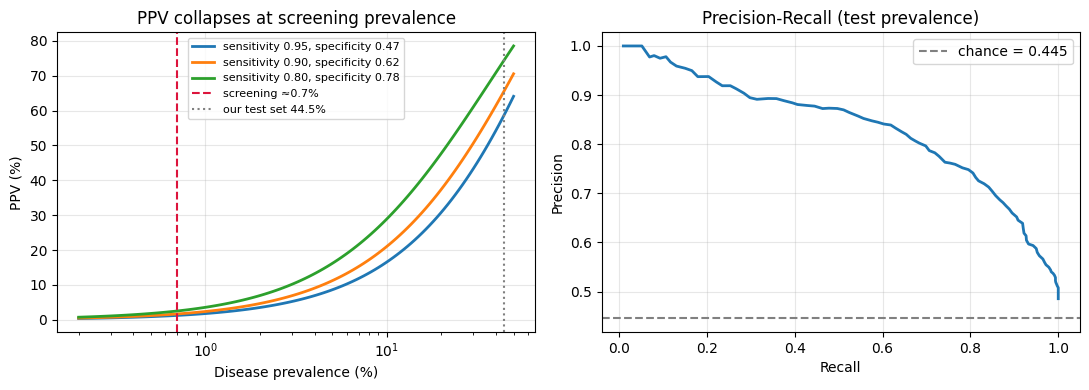

In [ ]:
prevs = np.logspace(np.log10(0.002), np.log10(0.5), 120)
plt.figure(figsize=(11,4))

plt.subplot(1,2,1)
for target in (0.95, 0.90, 0.80):
    i = int(np.argmin(np.abs(tpr - target)))
    plt.plot(prevs*100, [100*ppv(tpr[i], spec[i], p) for p in prevs],
             lw=2, label=f'sensitivity {tpr[i]:.2f}, specificity {spec[i]:.2f}')
plt.axvline(0.7, color='crimson', ls='--', lw=1.5, label='screening ≈0.7%')
plt.axvline(44.5, color='grey', ls=':', lw=1.5, label='our test set 44.5%')
plt.xscale('log'); plt.xlabel('Disease prevalence (%)'); plt.ylabel('PPV (%)')
plt.title('PPV collapses at screening prevalence'); plt.legend(fontsize=8); plt.grid(alpha=.3)

plt.subplot(1,2,2)
prec, rec = [], []
for t in np.linspace(0.01, 0.99, 99):
    p = (scores >= t).astype(int)
    if p.sum() == 0: continue
    prec.append(precision_score(y_bin, p, zero_division=0)); rec.append(recall_score(y_bin, p))
plt.plot(rec, prec, lw=2)
plt.axhline(y_bin.mean(), ls='--', c='grey', label=f'chance = {y_bin.mean():.3f}')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall (test prevalence)'); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 6. Bootstrap confidence intervals

Run-to-run variance on malignant recall was measured at roughly 3 points between identical
configurations. Several differences in the master results table sit inside that band. Patient-level
resampling, 1,000 draws.

In [ ]:
pat_ids = test_df['source_subjectID'].to_numpy()
uniq = np.unique(pat_ids)
idx_by_pat = {p: np.where(pat_ids == p)[0] for p in uniq}
rng = np.random.default_rng(SEED)
B = 1000

def boot(probs, coef=None):
    acc, mf1, mrec, bf1, auc, mcc = [], [], [], [], [], []
    for _ in range(B):
        samp = rng.choice(uniq, size=len(uniq), replace=True)
        idx = np.concatenate([idx_by_pat[p] for p in samp])
        y, p = test_labels[idx], probs[idx]
        pr = (p * coef).argmax(1) if coef is not None else p.argmax(1)
        if len(np.unique(y)) < 3: continue
        f1s = f1_score(y, pr, average=None, labels=[0,1,2], zero_division=0)
        acc.append(accuracy_score(y, pr)); mf1.append(f1_score(y, pr, average='macro', zero_division=0))
        mrec.append(recall_score(y, pr, labels=[MAL], average='macro', zero_division=0))
        bf1.append(f1s[1]); mcc.append(matthews_corrcoef(y, pr))
        auc.append(roc_auc_score(y, p, multi_class='ovr', average='macro'))
    def ci(a):
        a = np.array(a); return a.mean(), np.percentile(a,2.5), np.percentile(a,97.5)
    return {'accuracy': ci(acc), 'macro_f1': ci(mf1), 'mal_recall': ci(mrec),
            'benign_f1': ci(bf1), 'macro_auc': ci(auc), 'mcc': ci(mcc)}

res_ci = boot(test_ens, COEF)
print('FINAL CONFIGURATION — 95% bootstrap CI over 831 patients\n')
for k, (m, lo, hi) in res_ci.items():
    print(f'  {k:12s} {m:.4f}   [{lo:.4f}, {hi:.4f}]   width {hi-lo:.4f}')

print('\nAny difference in the master table smaller than these CI widths is not')
print('distinguishable from noise and should be reported as such.')

FINAL CONFIGURATION — 95% bootstrap CI over 831 patients

  accuracy     0.7371   [0.7134, 0.7618]   width 0.0484
  macro_f1     0.7411   [0.7164, 0.7654]   width 0.0489
  mal_recall   0.7805   [0.7482, 0.8135]   width 0.0653
  benign_f1    0.6335   [0.5898, 0.6745]   width 0.0847
  macro_auc    0.8916   [0.8771, 0.9049]   width 0.0278
  mcc          0.5902   [0.5512, 0.6311]   width 0.0799

Any difference in the master table smaller than these CI widths is not
distinguishable from noise and should be reported as such.


## 7. Selective prediction — the abstention curve

Radiology 2025: a hybrid uncertain-case deferral strategy reduced radiologist workload 38%
while holding recall near 23.6 per 1,000 and cancer detection near 6.6 per 1,000. Your ECE
of 0.033 is what makes this possible — an uncalibrated model cannot know when it doesn't
know.

,n_auto,n_deferred,accuracy,macro_f1,mal_recall,malignant_in_deferred
coverage,,,,,,
1.00,2821,0,0.7373,0.7415,0.7811,0
0.95,2679,142,0.7533,0.7553,0.7977,45
0.90,2538,283,0.7648,0.7657,0.8039,114
0.85,2397,424,0.7822,0.7814,0.8185,187
0.80,2256,565,0.8005,0.7974,0.8333,260
0.75,2115,706,0.8184,0.8128,0.8394,316
0.70,1974,847,0.8354,0.8276,0.8498,384
0.65,1833,988,0.8522,0.8423,0.8612,442
0.60,1692,1129,0.8664,0.8535,0.8685,503


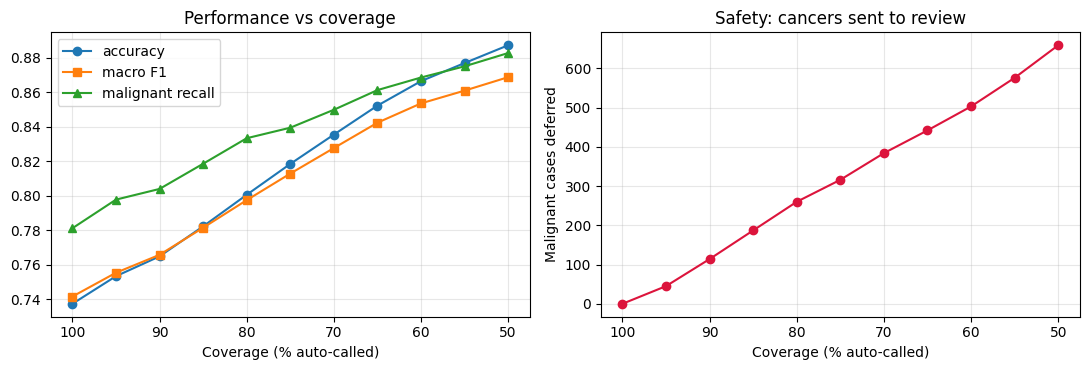

In [ ]:
margin  = np.sort(test_ens, 1)[:, -1] - np.sort(test_ens, 1)[:, -2]   # top-2 margin
entropy = -(test_ens * np.log(test_ens + 1e-12)).sum(1)

rows = []
for cov in np.arange(1.0, 0.45, -0.05):
    k = int(len(margin) * cov)
    keep = np.argsort(-margin)[:k]                      # most confident
    defer = np.setdiff1d(np.arange(len(margin)), keep)
    y, p = test_labels[keep], test_ens[keep]
    pr = (p * COEF).argmax(1)
    rows.append({'coverage': round(cov,2),
                 'n_auto': k, 'n_deferred': len(defer),
                 'accuracy': accuracy_score(y, pr),
                 'macro_f1': f1_score(y, pr, average='macro', zero_division=0),
                 'mal_recall': recall_score(y, pr, labels=[MAL], average='macro', zero_division=0),
                 'malignant_in_deferred': int((test_labels[defer] == MAL).sum())})
sel = pd.DataFrame(rows).set_index('coverage').round(4)
display(sel)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(sel.index*100, sel.accuracy, 'o-', label='accuracy')
ax[0].plot(sel.index*100, sel.macro_f1, 's-', label='macro F1')
ax[0].plot(sel.index*100, sel.mal_recall, '^-', label='malignant recall')
ax[0].set_xlabel('Coverage (% auto-called)'); ax[0].set_title('Performance vs coverage')
ax[0].invert_xaxis(); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(sel.index*100, sel.malignant_in_deferred, 'o-', color='crimson')
ax[1].set_xlabel('Coverage (% auto-called)'); ax[1].set_ylabel('Malignant cases deferred')
ax[1].set_title('Safety: cancers sent to review'); ax[1].invert_xaxis(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 8. Save

In [ ]:
summary = {
  'final_config': {'members': BEST, 'weights': {k: float(v) for k,v in W_BEST.items()},
                   'class_coef': COEF.tolist()},
  'bootstrap_ci': {k: [float(x) for x in v] for k, v in res_ci.items()},
  'source_ablation': res.reset_index().to_dict('records'),
  'per_source': per_src.reset_index().to_dict('records'),
  'screening_metrics': sc.reset_index().to_dict('records'),
  'selective_prediction': sel.reset_index().to_dict('records'),
}
with open(os.path.join(OUT_DIR, 'audit_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2, default=float)
per_src.to_csv(os.path.join(OUT_DIR, 'per_source.csv'))
sc.to_csv(os.path.join(OUT_DIR, 'screening_metrics.csv'))
sel.to_csv(os.path.join(OUT_DIR, 'selective_prediction.csv'))
print('Saved to', OUT_DIR)

Saved to /content/drive/MyDrive/momobench-dataset/sprint4_audit


## What to do with the results

**Section 3 gates everything.** If masking the source embedding costs more than about
3 points, retrain v5 and v6 without it before making any generalisation claim — the current
baseline is partly dataset recognition. If it costs under 1 point, the image features carry
the model and you can proceed.

**Section 2** tells you whether Benign is a modelling problem or a labelling problem. A wide
Benign F1 spread across sources points at inconsistent label construction, which no loss
function will fix.

**Section 5** is the number that belongs in the report. AUC is prevalence-invariant; PPV is
not. Reporting PPV at screening prevalence alongside the curated-set figures is what
separates a measured result from an unsupported clinical claim.

**Section 7** is the differentiator. Find the coverage where malignant recall among
auto-called cases is highest while deferred cancers stay near zero — that is the operating
point for a decision-support tool, and no deployed mammography system offers it.